<a href="https://colab.research.google.com/github/sahilmohd-10/Trader-Behavioral-Analysis-Sentiment-vs.-Performance/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Load Data***

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
dfs=pd.read_csv("/content/fear_greed_index.csv")
dft=pd.read_csv("/content/historical_data.csv")
dft.shape,dfs.shape


((211224, 16), (2644, 4))

# **Cheak Null Values**

In [69]:
dfs.duplicated().sum(),dfs.isnull().sum()

(np.int64(0),
 timestamp         0
 value             0
 classification    0
 date              0
 dtype: int64)

In [70]:
dft.duplicated().sum(),dft.isnull().sum()

(np.int64(0),
 Account             0
 Coin                0
 Execution Price     0
 Size Tokens         0
 Size USD            0
 Side                0
 Timestamp IST       0
 Start Position      0
 Direction           0
 Closed PnL          0
 Transaction Hash    0
 Order ID            0
 Crossed             0
 Fee                 0
 Trade ID            0
 Timestamp           0
 dtype: int64)

# **Convert timestamps and align the datasets by date (daily level is fine)**

In [71]:
dft['Timestamp IST'] = pd.to_datetime(dft['Timestamp IST'], format='%d-%m-%Y %H:%M')
dft['date'] = dft['Timestamp IST'].dt.normalize()
dft['Timestamp IST']

,Timestamp IST
0,2024-12-02 22:50:00
1,2024-12-02 22:50:00
2,2024-12-02 22:50:00
3,2024-12-02 22:50:00
4,2024-12-02 22:50:00
...,...
211219,2025-04-25 15:35:00
211220,2025-04-25 15:35:00
211221,2025-04-25 15:35:00
211222,2025-04-25 15:35:00


In [72]:
dfs['date'] = pd.to_datetime(dfs['date']).dt.normalize()
dfs['date']

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05
...,...
2639,2025-04-28
2640,2025-04-29
2641,2025-04-30
2642,2025-05-01


In [73]:
df = dft.merge(dfs, on='date', how='inner')
df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211213,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,1745559000,60,Greed
211214,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,1745559000,60,Greed
211215,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,1745559000,60,Greed
211216,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,1745559000,60,Greed


## **4. Metric Creation (Daily Level per Account)**

In [74]:
daily_metrics = df.groupby(['Account', 'date', 'classification', 'value']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    total_trades=('Trade ID', 'count'),
    win_count=('Closed PnL', lambda x: (x > 0).sum()),
    avg_trade_size=('Size USD', 'mean'),
    long_count=('Side', lambda x: (x == 'BUY').sum()),
    short_count=('Side', lambda x: (x == 'SELL').sum())
).reset_index()


In [75]:
daily_metrics['win_rate'] = daily_metrics['win_count'] / daily_metrics['total_trades']
daily_metrics['ls_ratio'] = daily_metrics['long_count'] / daily_metrics['short_count']
daily_metrics['ls_ratio'] = daily_metrics['ls_ratio'].replace([np.inf, -np.inf], 10) # Cap for analysis


In [76]:
# Group sentiment into broader categories for cleaner analysis
def group_sentiment(label):
    if 'Fear' in label: return 'Fear'
    if 'Greed' in label: return 'Greed'
    return 'Neutral'

daily_metrics['sentiment_group'] = daily_metrics['classification'].apply(group_sentiment)

# **Analysis & Segmentation**

In [77]:
performance = daily_metrics.groupby('sentiment_group').agg(
    mean_pnl=('daily_pnl', 'mean'),
    win_rate=('win_rate', 'mean'),
    avg_trades_per_day=('total_trades', 'mean'),
    avg_pos_size=('avg_trade_size', 'mean')
).round(2)

print("\n--- Performance & Behavior Summary ---")
print(performance)

# 2. Identify Segments
trader_profiles = daily_metrics.groupby('Account').agg(
    lifetime_pnl=('daily_pnl', 'sum'),
    avg_daily_trades=('total_trades', 'mean'),
    avg_pos_size=('avg_trade_size', 'mean')
).reset_index()

# Segment Definitions
whale_thresh = trader_profiles['avg_pos_size'].quantile(0.75)
freq_thresh = trader_profiles['avg_daily_trades'].median()

def segment_logic(row):
    if row['avg_pos_size'] > whale_thresh: return 'Whale'
    if row['avg_daily_trades'] > freq_thresh: return 'Frequent Retail'
    return 'Occasional Retail'

trader_profiles['segment'] = trader_profiles.apply(segment_logic, axis=1)

# Map segments back to main metrics
daily_metrics = daily_metrics.merge(trader_profiles[['Account', 'segment']], on='Account')


--- Performance & Behavior Summary ---
                 mean_pnl  win_rate  avg_trades_per_day  avg_pos_size
sentiment_group                                                      
Fear              5185.15      0.36              105.36       8529.86
Greed             4144.21      0.36               76.91       5954.63
Neutral           3438.62      0.36              100.23       6963.69


# **Visualization & Output**

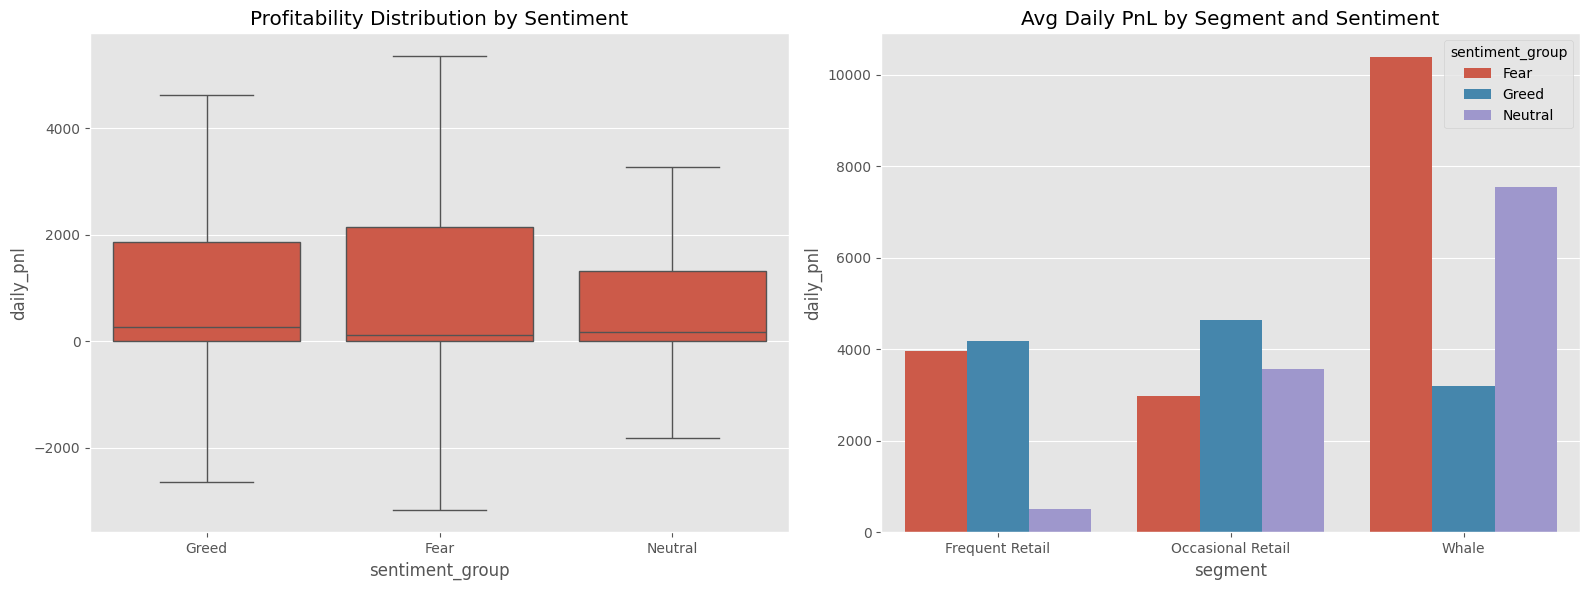

In [78]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Daily PnL by Sentiment
sns.boxplot(x='sentiment_group', y='daily_pnl', data=daily_metrics, ax=axes[0], showfliers=False)
axes[0].set_title('Profitability Distribution by Sentiment')

# Chart 2: PnL by Segment and Sentiment
segment_pnl = daily_metrics.groupby(['segment', 'sentiment_group'])['daily_pnl'].mean().reset_index()
sns.barplot(x='segment', y='daily_pnl', hue='sentiment_group', data=segment_pnl, ax=axes[1])
axes[1].set_title('Avg Daily PnL by Segment and Sentiment')

plt.tight_layout()
plt.savefig('trading_behavior_analysis.png')

daily_metrics.to_csv('processed_daily_trader_metrics.csv', index=False)
